In [194]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings

In [195]:
warnings.filterwarnings('ignore')

In [196]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# EDA

In [197]:
df.shape

(1338, 7)

In [198]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [199]:
# df.describe(include='all')
# df.describe(include='object')
df.describe()
# df.describe

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [200]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [201]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

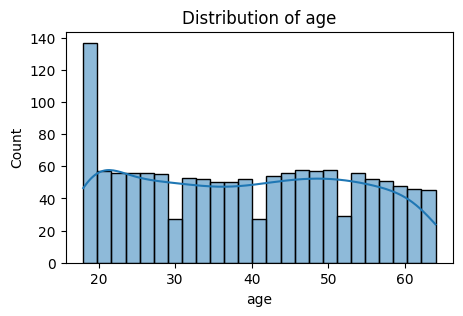

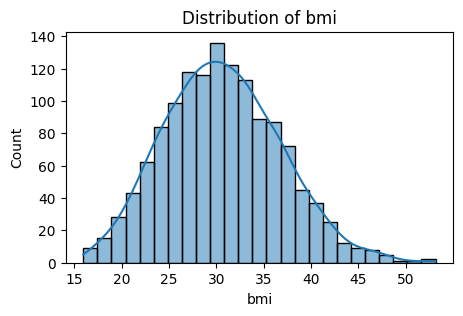

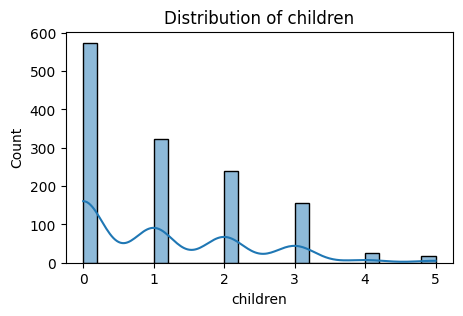

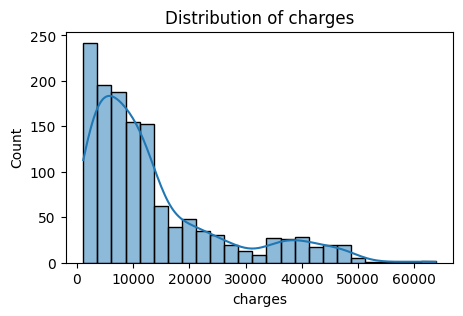

In [202]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_col = ['age', 'bmi', 'children', 'charges']

for col in numeric_col:

    plt.figure(figsize=(5, 3))

    sns.histplot(
        df[col],
        kde=True,
        bins=25
    )

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    # plt.ylabel('Frequency')

    plt.show()

<Axes: xlabel='children', ylabel='count'>

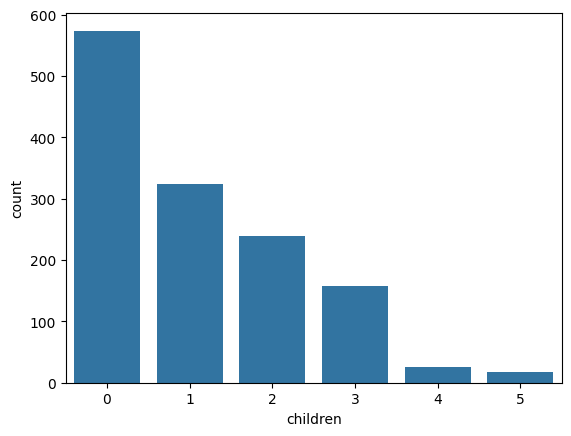

In [203]:
sns.countplot(x=df['children'])

<Axes: xlabel='smoker', ylabel='count'>

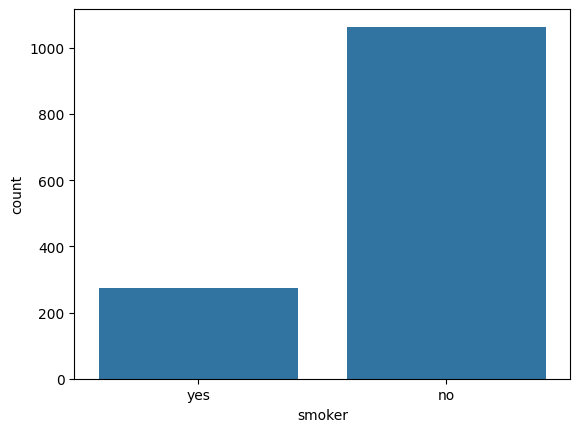

In [204]:
sns.countplot(x=df['smoker'])

<Axes: xlabel='region', ylabel='count'>

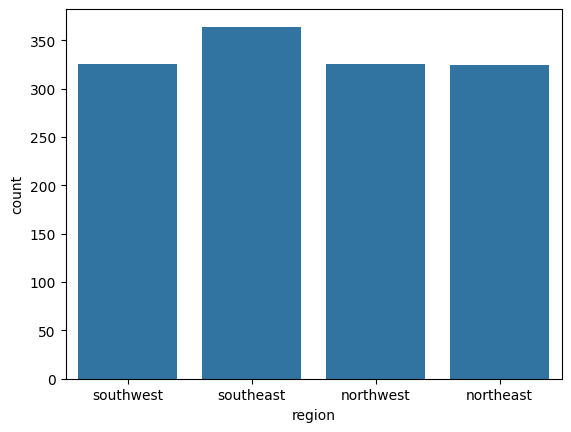

In [205]:
sns.countplot(x=df['region'])

<Axes: xlabel='sex', ylabel='count'>

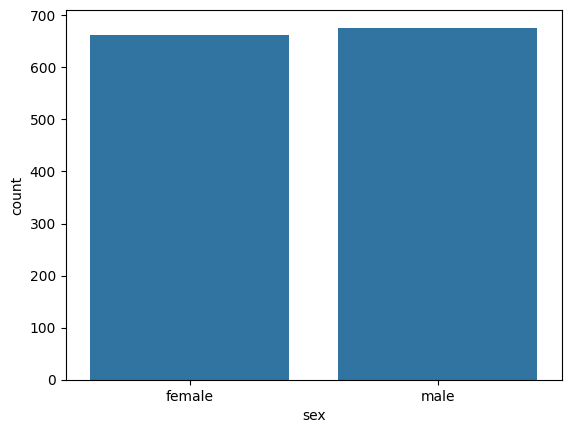

In [206]:
sns.countplot(x=df['sex'])

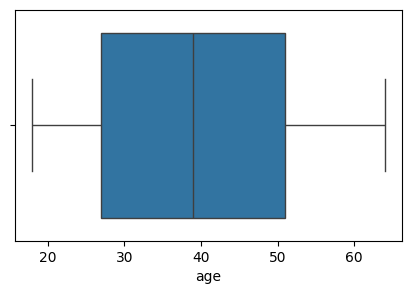

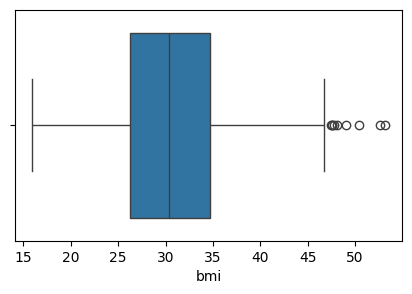

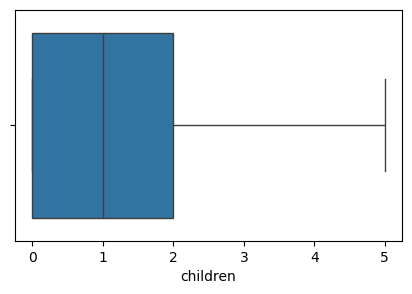

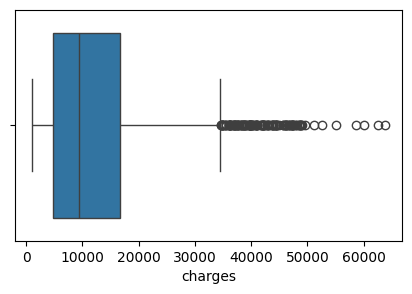

In [207]:
for col in numeric_col:
    plt.figure(figsize=(5,3))
    sns.boxplot(x = df[col])

In [208]:
numeric_col

['age', 'bmi', 'children', 'charges']

<Axes: >

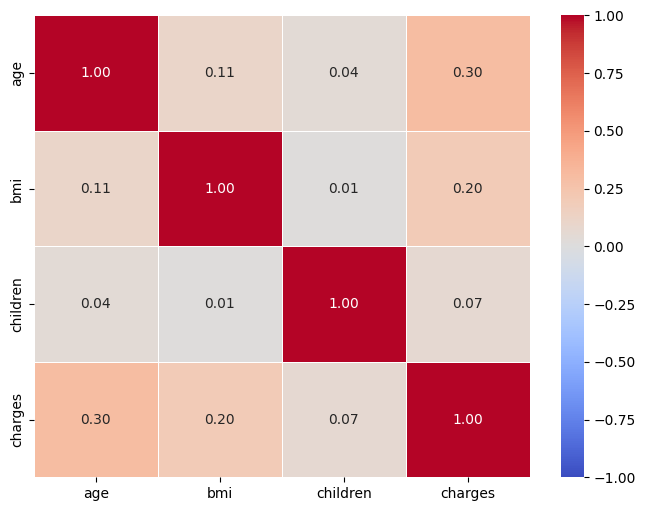

In [209]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df.corr(numeric_only=True), 
    annot=True,
    cmap='coolwarm',
    fmt= '.2f',
    linewidths=0.5,
    vmin=-1,
    vmax=1
    )
# plt.show()

# Data Cleaning and Pre-processing

In [210]:
# data is clean so i will make copy
copy_df = df.copy()
copy_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [211]:
copy_df.shape

(1338, 7)

In [212]:
duplicate = copy_df.duplicated()
copy_df[duplicate]


,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [213]:
copy_df.drop_duplicates(inplace=True)

In [214]:
copy_df.shape

(1337, 7)

In [215]:
copy_df['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [216]:
# from sklearn.preprocessing import LabelEncoder

# le = LabelEncoder()

# copy_df['sex'] = le.fit_transform(copy_df['sex'])
# copy_df['sex']

In [217]:
copy_df['sex'] = copy_df['sex'].map({
    'male':0,
    'female':1
})
copy_df['sex']

0       1
1       0
2       0
3       0
4       0
       ..
1333    0
1334    1
1335    1
1336    1
1337    1
Name: sex, Length: 1337, dtype: int64

In [218]:
copy_df['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [219]:
copy_df['smoker'] = copy_df['smoker'].map({
    'no':0,
    "yes":1
})
copy_df['smoker']

0       1
1       0
2       0
3       0
4       0
       ..
1333    0
1334    0
1335    0
1336    0
1337    1
Name: smoker, Length: 1337, dtype: int64

In [220]:
copy_df

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,northwest,10600.54830
1334,18,1,31.920,0,0,northeast,2205.98080
1335,18,1,36.850,0,0,southeast,1629.83350
1336,21,1,25.800,0,0,southwest,2007.94500


In [221]:
copy_df.rename(columns={
    'sex':"is_female",
    'smoker':'is_smoker'
}, inplace=True)

copy_df

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,northwest,10600.54830
1334,18,1,31.920,0,0,northeast,2205.98080
1335,18,1,36.850,0,0,southeast,1629.83350
1336,21,1,25.800,0,0,southwest,2007.94500


### one-hot encoding

In [222]:
clean_df = pd.get_dummies(copy_df,columns=['region'],drop_first=True)

In [223]:
clean_df.astype(int)


,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0
1334,18,1,31,0,0,2205,0,0,0
1335,18,1,36,0,0,1629,0,1,0
1336,21,1,25,0,0,2007,0,0,1


# Feature Enginering and Extraction

In [224]:
clean_df['bmi_category'] = pd.cut(
    clean_df['bmi'],
    bins=[0, 18.5, 24.9, 29.9, float('inf')],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)
clean_df

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27.900,0,1,16884.92400,False,False,True,Overweight
1,18,0,33.770,1,0,1725.55230,False,True,False,Obese
2,28,0,33.000,3,0,4449.46200,False,True,False,Obese
3,33,0,22.705,0,0,21984.47061,True,False,False,Normal
4,32,0,28.880,0,0,3866.85520,True,False,False,Overweight
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,True,False,False,Obese
1334,18,1,31.920,0,0,2205.98080,False,False,False,Obese
1335,18,1,36.850,0,0,1629.83350,False,True,False,Obese
1336,21,1,25.800,0,0,2007.94500,False,False,True,Overweight


In [225]:
clean_df['bmi_category'].value_counts()

bmi_category
Obese          715
Overweight     380
Normal         221
Underweight     21
Name: count, dtype: int64

In [226]:
# converting 'bmi catagory' into numerical by one-hot encoding

clean_df = pd.get_dummies(clean_df, columns=['bmi_category'], drop_first=True )
clean_df

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27.900,0,1,16884.92400,False,False,True,False,True,False
1,18,0,33.770,1,0,1725.55230,False,True,False,False,False,True
2,28,0,33.000,3,0,4449.46200,False,True,False,False,False,True
3,33,0,22.705,0,0,21984.47061,True,False,False,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,True,False,False,False,False,True
1334,18,1,31.920,0,0,2205.98080,False,False,False,False,False,True
1335,18,1,36.850,0,0,1629.83350,False,True,False,False,False,True
1336,21,1,25.800,0,0,2007.94500,False,False,True,False,True,False


In [231]:
clean_df = clean_df.astype(int)
clean_df.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0
